<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/2026_DSLab2_a3(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DS Lab2 - Assignment 3: Making a Discovery in the AirBnB Dataset**

This is the final assessment for DSLab2, giving you chance to bring together the full skillset you have acquired over the course of the module. Note that this assignment makes up the final 40% of the grade for the module. \\

Please make sure you use the software versions specified in this notebook, rather than the latest or other versions.

**Task**

**Visit the Inside AirBnB website and choose at least 3 locations in Australia that you would be interested in comparing.** \\

(Note - if you have problems in Chrome try downloading in Safari or some other browser) \\

You may employ any of the tools we have encountered so far in the module. Choose or switch interchangably between Pandas, PySpark, Dask, and PyTorch, as well as all the usual Python packages (e.g. numpy, matplotlib), and string manipulation tools if required. \\

A greater degree of independence is expected in choosing the correct tools for a particular task in this assignment, and your analysis should be thorough and well documented. Marks will be assigned for the quality of your code, including clarity, commenting and appropriate visualisations e.g. histograms, scatterplots etc. \\

**To Submit:**

1.   **This notebook containing your code and visualizations**
      - Please name the file "YOUR_NAME_DSLab226_a3.ipynb" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be in .ipynb format - markers will check that your code runs successfully.

2.  **All data files that are needed to run your code**
      - e.g. If you work on the detailed reviews from Sydney, **you must submit the csv file** of Sydney's detailed reviews with your code and report so we can run the code.

3.   **1-page report summarising your work and findings**
      - Please name the file "YOUR_NAME_DSLab226_a3_report.pdf" (i.e. update "YOUR NAME" to be your name...)
      - The file *must* be submitted in PDF format - LaTEX is recommended to generate your report, but you will not be penalised for a well-presented Word document exported as a PDF.
      - Please aim to provide your full report within 2 sides of A4 (marks will be lost for reports less than 1 side of A4 or for reports greater than 2 sides of A4.)



# Setup

In [3]:
## Generic setup that we have used every week - this time they need to set up themselves
## Mount your Google Drive so we can access the data
from google.colab import drive
drive.mount('/content/drive',  force_remount=True)

Mounted at /content/drive


In [4]:
## Import useful python modules
import pandas as pd ## to read in and explore data
import numpy as np ## Useful for calculations
import matplotlib.pyplot as plt ## Useful for plotting
import matplotlib.gridspec as gridspec ## Useful for plotting

In [5]:
## Importing PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Q1 - Classification Problem
**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions**

Design and implement a classification problem that can be applied to each of your locations. You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable classification algorithm
*   Visualise the output of your classifications using at least one appropriate plot
*   Apply your technique to at least two different locations
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider one of the following problems**

(no marks gained or lost for using a suggested problem vs an original problem):

1.   By treating "`review_score_rating`" as a discrete variable (i.e. a series of distinct bins) construct a model to predict which of your chosen categories a given listing will fall into, e.g. excellent, good, intermediate, poor, rubbish or similar. \\

2.   Use sentiment analysis to classify reviews (i.e. "`comments`" column) into positive, neutral, or negative sentiment categories. Compare the overall satisfaction level with AirBnB listings across different cities (probably best to use at least 3 locations).  \\


Feel free to develop either of these ideas or one of your own, and see where the analysis takes you. You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. \\

\\



# Load Data

In [8]:
data = pd.read_csv('/content/listings.csv.gz')
df = pd.DataFrame(data)
df.head(3)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21302,https://www.airbnb.com/rooms/21302,20250928035044,2025-09-28,city scrape,Great Ocean Haven,If you are looking for a beach house to relax ...,We are situated minutes walking distance to th...,https://a0.muscache.com/pictures/hosting/Hosti...,81292,...,4.98,4.94,4.63,NaN,f,3,2,1,0,0.40
1,27561,https://www.airbnb.com/rooms/27561,20250928035044,2025-09-28,city scrape,Executive residence peaceful locale,A spacious retreat in a perfect location to re...,The area is generally quiet but seasonal touri...,https://a0.muscache.com/pictures/153948/809ee1...,119103,...,5.00,5.00,5.00,NaN,f,2,1,1,0,0.03
2,70449,https://www.airbnb.com/rooms/70449,20250928035044,2025-09-28,city scrape,Otway foothills retreat,"Modern 2 bedroom house with 2 bathrooms, kitch...",NaN,https://a0.muscache.com/pictures/450690/937a7e...,357052,...,4.94,4.83,4.67,NaN,f,1,1,0,0,0.50


# Clean Data

In [17]:
dfc = df[['host_is_superhost',
          'host_since',
          'reviews_per_month', 'price',
          'host_has_profile_pic',
          'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication']].dropna()

In [18]:
dfc['price2'] = dfc['price'].str.replace('$', '').str.replace(',', '').astype('float')
dfc['price2'].head()

,price2
0,814.0
1,363.0
2,156.0
3,459.0
4,600.0


Removing outliers

In [20]:
q3 = np.percentile(dfc['price2'], 75)
q1 = np.percentile(dfc['price2'], 25)
iqr = q3 - q1

upper_lim = q3 + (iqr * 1.5)
dfc1 = dfc[dfc['price2'] < upper_lim]
print(len(dfc1) / len(dfc))

0.9467930029154519


EDA

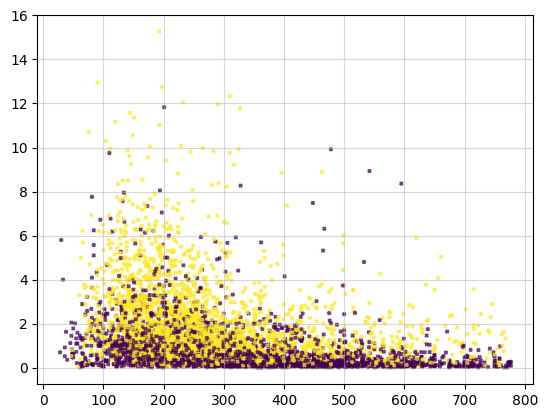

In [23]:
plt.scatter(dfc1['price2'], dfc1['reviews_per_month'], c= dfc1['host_is_superhost'].map({'t': 1, 'f': 0}), alpha=0.75, marker = 'x', s=5)
plt.grid(alpha=0.5)
plt.show()

Investigating potential transformations for skewed review_scores variables

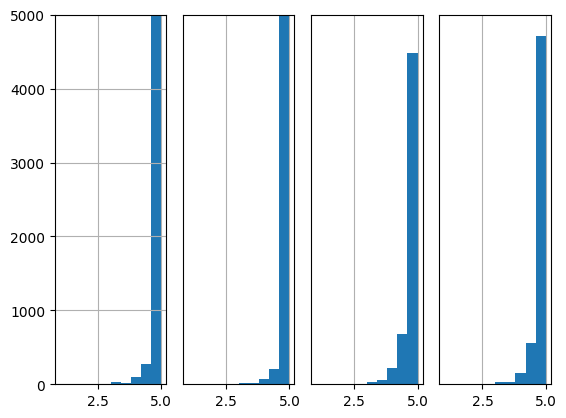

In [21]:
plt.subplot(1, 4, 1)
plt.ylim(0, 5000)
plt.subplots_adjust(wspace = .15)
plt.grid(False)
dfc['review_scores_communication'].hist()

plt.subplot(1, 4, 2)
plt.ylim(0, 5000)
plt.yticks([])
dfc['review_scores_checkin'].hist()

plt.subplot(1, 4, 3)
plt.ylim(0, 5000)
plt.yticks([])
dfc['review_scores_cleanliness'].hist()

plt.subplot(1, 4, 4)
plt.ylim(0, 5000)
plt.yticks([])
dfc['review_scores_rating'].hist()

plt.show()

In [22]:
def skew(x):
  return (3* (np.mean(x) - np.median(x))) / (np.std(x))

print(skew(dfc['review_scores_checkin']))

-0.9137249321660161


Not much change: find other variables

In [ ]:
dfc2 = df[['host_is_superhost',
        'host_since',
        'reviews_per_month',
        'host_has_profile_pic',
        'host_listings_count', 'host_total_listings_count',
        'host_identity_verified',
        'amenities']]

dfc2['price'] = dfc1['price']

Feature Engineering

In [ ]:
amenities_count = []

for row in dfc2['amenities'] :
  amenities_count.append(len(str(row).split(',')))

dfc2['amenities_count'] = amenities_count

In [ ]:
from datetime import datetime

current = datetime.now()
dfc2['host_since'] = pd.to_datetime(dfc2['host_since'])
dfc2['host_exp'] = ((current - dfc2['host_since']) / pd.Timedelta(days= 365.25))

dfc2['host_exp'].head(3)
dfc2 = dfc2.drop(columns = ['host_since'])

In [28]:
dfc2['host_listing_ratio'] = dfc2['host_listings_count'] / dfc2['host_total_listings_count']

In [29]:
dfcf = dfc2.drop(columns = ['amenities', 'host_listings_count', 'host_total_listings_count']).dropna()    #f is for final
dfcf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5196 entries, 1 to 7248
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   host_is_superhost       5196 non-null   object 
 1   reviews_per_month       5196 non-null   float64
 2   host_has_profile_pic    5196 non-null   object 
 3   host_identity_verified  5196 non-null   object 
 4   price                   5196 non-null   object 
 5   amenities_count         5196 non-null   int64  
 6   host_exp                5196 non-null   float64
 7   host_listing_ratio      5196 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 365.3+ KB


In [30]:
dfcf['price'] = dfcf['price'].str.replace('$', '').str.replace(',', '').astype('float')

# Classification

In [31]:
import torch.nn as nn
import torch.optim as optim

In [32]:
X = dfcf.drop(columns = ['host_is_superhost'])
y = dfcf['host_is_superhost']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

sscaler =StandardScaler()

#only price looks to really need scaling
price_scaled_train = sscaler.fit_transform(X_train[['price']])
price_scaled_test = sscaler.transform(X_test[['price']])

Encoding

In [34]:
from sklearn.preprocessing import OneHotEncoder

oh_X = OneHotEncoder(sparse_output= False, handle_unknown='ignore')

catcols_encoded_train = oh_X.fit_transform(X_train[['host_has_profile_pic', 'host_identity_verified']])
catcols_encoded_test = oh_X.transform(X_test[['host_has_profile_pic', 'host_identity_verified']])

oh_y = OneHotEncoder(sparse_output= False, handle_unknown='ignore')

y_enc_train = oh_y.fit_transform(y_train.values.reshape(-1, 1))
y_enc_test = oh_y.transform(y_test.values.reshape(-1, 1))

Collecting everything back together and turning into tensors

In [39]:
import numpy as np
import torch

#X_train
no_process_cols = ['reviews_per_month', 'amenities_count', 'host_exp', 'host_listing_ratio']

all_X_train = [X_train[no_process_cols].values,
               price_scaled_train,
               catcols_encoded_train]

X_train_tensor = torch.tensor(np.hstack(all_X_train), dtype=torch.float32)

#y train mapping and collection
y_train_mapped = y_train.map({'t': 1, 'f': 0}).values
y_train_tensor = torch.tensor(y_train_mapped, dtype = torch.long)

#x test
no_process_cols = ['reviews_per_month', 'amenities_count', 'host_exp', 'host_listing_ratio']

all_X_test = [X_test[no_process_cols].values,
               price_scaled_test,
               catcols_encoded_test]

X_test_tensor = torch.tensor(np.hstack(all_X_test), dtype = torch.float32)

#y test
y_test_mapped = y_test.map({'t': 1, 'f': 0}).values
y_test_tensor = torch.tensor(y_test_mapped, dtype = torch.long)

#NN: input and output
inputs = X_train_tensor.shape[1]
outputs = 2

Building

In [40]:
import torch.nn.functional as F

class MyNN(nn.Module):

  #initialise variables >>>
  def __init__(self, input_dim, output_dim):
    #initialise nn module
    super(MyNN, self).__init__()
    #first layer
    self.linear1 = torch.nn.Linear(input_dim, 64)
    #relu
    self.relu_act1 = nn.ReLU()
    self.linear2 = torch.nn.Linear(64, 32)
    self.relu_act2 = nn.ReLU()
    self.output_layer = torch.nn.Linear(32, output_dim)

  #how forward pass is handled
  def forward(self, x):
    x = self.linear1(x)
    x = self.relu_act1(x)
    x = self.linear2(x)
    x = self.relu_act2(x)
    logits = self.output_layer(x)
    #NOT YET probabilities
    return logits

In [43]:
hidden_layers = 64    #upped from 32
model = MyNN(inputs, outputs)
print(model.parameters())

<generator object Module.parameters at 0x7969d82bfca0>


Loss function and optimiser

In [44]:
loss_func = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr = 0.01)    #experimented with

In [45]:
X_train_tensor

tensor([[ 0.4100, 56.0000, 10.9041,  ...,  1.0000,  0.0000,  1.0000],
        [ 2.6700, 45.0000, 11.4955,  ...,  1.0000,  0.0000,  1.0000],
        [ 7.8200, 52.0000,  6.7426,  ...,  1.0000,  0.0000,  1.0000],
        ...,
        [ 1.1000, 61.0000,  8.2950,  ...,  1.0000,  0.0000,  1.0000],
        [ 4.8900, 47.0000,  3.8761,  ...,  1.0000,  0.0000,  1.0000],
        [ 1.8300, 61.0000,  9.4941,  ...,  1.0000,  0.0000,  1.0000]])

Training loop

In [46]:
epochs = 2500
for epoch in range(epochs):
  #no gradient accumulation to interfere with calculations
  opt.zero_grad()
  model_outputs = model(X_train_tensor)
  loss = loss_func(model_outputs, y_train_tensor)
  #backward pass to update params
  loss.backward()
  opt.step()
  if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [100/2500], Loss: 0.5377
Epoch [200/2500], Loss: 0.5204
Epoch [300/2500], Loss: 0.5189
Epoch [400/2500], Loss: 0.4997
Epoch [500/2500], Loss: 0.4873
Epoch [600/2500], Loss: 0.4769
Epoch [700/2500], Loss: 0.4802
Epoch [800/2500], Loss: 0.4612
Epoch [900/2500], Loss: 0.4539
Epoch [1000/2500], Loss: 0.4509
Epoch [1100/2500], Loss: 0.4529
Epoch [1200/2500], Loss: 0.4365
Epoch [1300/2500], Loss: 0.4337
Epoch [1400/2500], Loss: 0.4300
Epoch [1500/2500], Loss: 0.4265
Epoch [1600/2500], Loss: 0.4200
Epoch [1700/2500], Loss: 0.4188
Epoch [1800/2500], Loss: 0.4334
Epoch [1900/2500], Loss: 0.4112
Epoch [2000/2500], Loss: 0.4067
Epoch [2100/2500], Loss: 0.4283
Epoch [2200/2500], Loss: 0.4031
Epoch [2300/2500], Loss: 0.4002
Epoch [2400/2500], Loss: 0.3969
Epoch [2500/2500], Loss: 0.3970


Evaluate

In [48]:
with torch.no_grad():
  preds = model(X_test_tensor)
  testloss = loss_func(preds, y_test_tensor)
  probs = torch.softmax(preds, dim=1)
  predicted_classes = torch.argmax(preds, dim=1).numpy()

#back to arrays for plotting
X_train_arr = X_train_tensor.numpy()
X_test_arr = X_test_tensor.numpy()

Visualisations

#Q2 - Regression Problem

**25 marks for developing appropriate code for the chosen problem**

**25 marks for a report documenting your choice of problem, motivation, rationale for the developed solution, results and conclusions** \\

# ADD **LABELS**

Design and implement a regression problem that can be applied to each of your locations (and potentially to a merged set of locations). You may focus on any problem that interests you, but make sure to include the following elements:


*   Clean the input dataframes by doing the following:

> Remove NaNs in your columns of interest \\
> Update the Dtype of any columns if necessary \\

*   Choose a suitable regression algorithm
*   Decide whether to include categorical data or not, and deal with it appropriately
*   Visualise the output of your algorithm using at least one appropriate plot per location
*   Apply your technique to at least two different locations
*   Evaluate the results
*   Describe the problem, the approach you have chosen, and the results in your accompanying report
*   Remember to comment your code to help the markers (and yourself!). Think about using functions wherever appropriate to make it easier to apply your code to multiple locations for example. \\

\\

**If you require inspiration, perhaps consider the following**

(no marks gained or lost for using a suggested problem vs an original problem):

* Either of the problems suggested in section one could be treated as a
regression problem. For instance, the average `review_score_rating` or `average sentiment` are esssentially continuous variables. If you used your own problem instead you might also consider whether it is possible to adapt it into a regression problem. \\


You may find it helpful to start by mapping out in comments the broad-brush steps of your analysis, then think about how to accomplish each stage. For certain tasks it may be appropriate to utilise the GPUs available through Google colab. To avoid being thrown off, perhaps develop your code using the CPU first, and speed things up when you have a working setup to explore your idea and the results. \\

\\



# Load Data

In [ ]:
## Load first chosen dataset into a Pandas (or PySpark/Dask) DataFrame

data = pd.read_csv('/content/listings.csv.gz')
df =pd.DataFrame(data)


In [ ]:
## A couple of lines to orientate oneself wrt the data, columns and dtypes.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7280 entries, 0 to 7279
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7280 non-null   int64  
 1   listing_url                                   7280 non-null   object 
 2   scrape_id                                     7280 non-null   int64  
 3   last_scraped                                  7280 non-null   object 
 4   source                                        7280 non-null   object 
 5   name                                          7280 non-null   object 
 6   description                                   7204 non-null   object 
 7   neighborhood_overview                         3240 non-null   object 
 8   picture_url                                   7280 non-null   object 
 9   host_id                                       7280 non-null   i

# Clean Data

<Axes: >

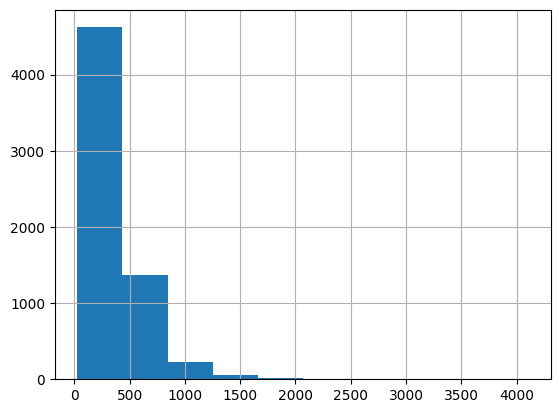

In [ ]:
df['price'] = df['price'].str.replace('$', '').str.replace(',', '').astype('float')
#df['logprice'] = np.log(df['price'])
df['price'].hist()

In [ ]:
amenities_count = []

for row in df['amenities'] :
  amenities_count.append(len(str(row).split(',')))

df['amenities_count'] = amenities_count

In [ ]:
import re

def clean_func(string):
  #ensure text is in fact strings
  text = str(string)
  #remove tags
  cleaner_text = re.sub('<[^<]+?>', '', text)
  full_clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', cleaner_text)
  return full_clean_text

df['clean_descs'] = df['description'].apply(clean_func)

from textblob import TextBlob

sentiment = []
polarity = []

def sentiment_analysis(text_input):
  analysis = TextBlob(str(text_input))
  return analysis.sentiment.polarity

for row in df['clean_descs']:
  sentiment.append(sentiment_analysis(row))

df['sentiments'] = sentiment
df = df.drop(columns=['clean_descs'])
df.head(3)
#len(df)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,sentiments
0,21302,https://www.airbnb.com/rooms/21302,20250928035044,2025-09-28,city scrape,Great Ocean Haven,If you are looking for a beach house to relax ...,We are situated minutes walking distance to th...,https://a0.muscache.com/pictures/hosting/Hosti...,81292,...,4.63,NaN,f,3,2,1,0,0.40,43,0.537500
1,27561,https://www.airbnb.com/rooms/27561,20250928035044,2025-09-28,city scrape,Executive residence peaceful locale,A spacious retreat in a perfect location to re...,The area is generally quiet but seasonal touri...,https://a0.muscache.com/pictures/153948/809ee1...,119103,...,5.00,NaN,f,2,1,1,0,0.03,69,0.368519
2,70449,https://www.airbnb.com/rooms/70449,20250928035044,2025-09-28,city scrape,Otway foothills retreat,"Modern 2 bedroom house with 2 bathrooms, kitch...",NaN,https://a0.muscache.com/pictures/450690/937a7e...,357052,...,4.67,NaN,f,1,1,0,0,0.50,28,0.200000


In [ ]:
from datetime import datetime

current = datetime.now()
df['host_since'] = pd.to_datetime(df['host_since'])
df['host_exp'] = ((current - df['host_since']) / pd.Timedelta(days= 365.25))

df['host_exp'].head(3)
df = df.drop(columns = ['host_since'])

In [ ]:
df['room_type'].unique()

array(['Entire home/apt', 'Private room', 'Hotel room', 'Shared room'],
      dtype=object)

In [ ]:
df1 = df[['reviews_per_month',  'sentiments' , 'bathrooms', 'review_scores_value', 'review_scores_rating', 'price', 'room_type', 'amenities_count', 'name']].dropna()

In [ ]:
df1.to_csv('/content/listing_data_1', index=False)

In [ ]:
!pip install pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
  .getOrCreate()

print(spark)

In [ ]:
spark_df = spark.read.option("header",True)\
  .option("multiLine",True)\
  .csv("/content/listing_data_1")

spark_df.show(5)

spark_df.createOrReplaceTempView("listings2")

#finding outliers
spark.sql("SELECT sentiments, price, name AS top_priced FROM listings2 ORDER BY price").show(5)


+-----------------+------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|reviews_per_month|        sentiments|bathrooms|review_scores_value|review_scores_rating|price|      room_type|amenities_count|                name|
+-----------------+------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|              0.4|            0.5375|      3.5|               4.63|                4.91|814.0|Entire home/apt|             43|   Great Ocean Haven|
|             0.03|0.3685185185185185|      2.5|                5.0|                 5.0|363.0|Entire home/apt|             69|Executive residen...|
|              0.5|               0.2|      2.0|               4.67|                4.85|156.0|Entire home/apt|             28|Otway foothills r...|
|             1.22|            0.3235|      2.5|               4.72|                4.85|459.0|Entire home

In [ ]:
df1['price'].describe()

,price
count,5657.000000
mean,349.245537
std,244.594299
min,28.000000
25%,198.000000
50%,288.000000
75%,430.000000
max,4105.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x789020bc4ef0>,
 'caps': [<matplotlib.lines.Line2D at 0x789020bf6210>,
 'boxes': [<matplotlib.lines.Line2D at 0x789020bb3b90>],
 'medians': [<matplotlib.lines.Line2D at 0x789020bf6e40>],
 'fliers': [<matplotlib.lines.Line2D at 0x789020bf7140>],
 'means': []}

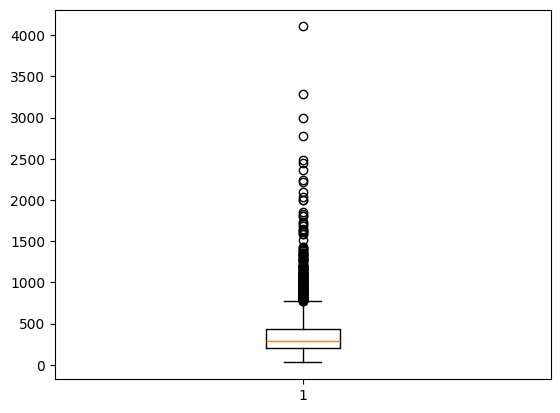

In [ ]:
plt.boxplot(df1['price'])

In [ ]:
#finding outliers amounts
q1 = np.percentile(df1['price'], 25)
q3 = np.percentile(df1['price'], 75)
iqr = q3 - q1
upper_lim = q3 + 1.5 * iqr
upper_pts_removed = df1[df1['price'] < upper_lim]
print(len(upper_pts_removed) / len(df1))

#no negative direction outliers

0.9482057627717871


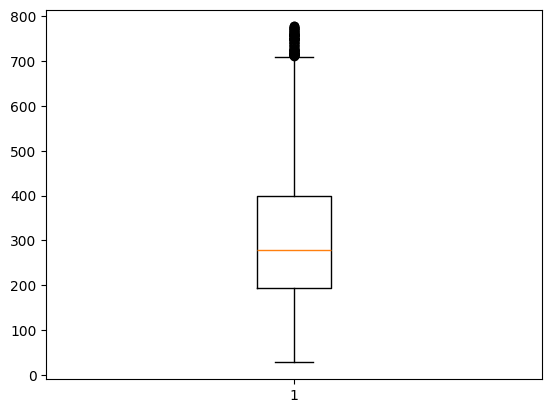

In [ ]:
plt.boxplot(upper_pts_removed['price'])
plt.show()

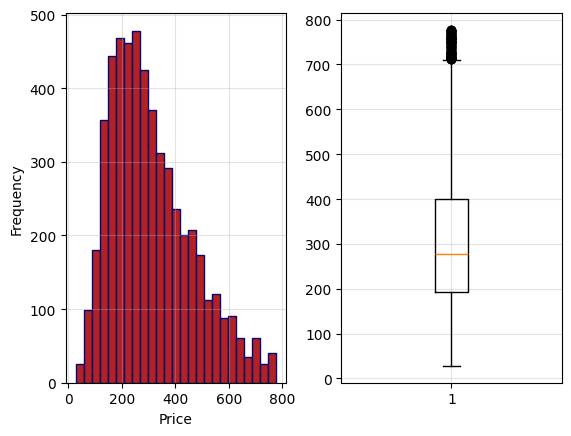

In [ ]:
plt.subplot(1, 2, 1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.grid(alpha=0.35)
plt.subplots_adjust(wspace = .25)
plt.hist(upper_pts_removed['price'], color= 'firebrick', edgecolor='navy', bins=25)

plt.subplot(1, 2, 2)
plt.boxplot(upper_pts_removed['price'])
plt.grid(alpha=0.35)
plt.show()

In [ ]:
upper_pts_removed['price'].describe()

,price
count,5364.000000
mean,309.387211
std,153.046560
min,28.000000
25%,193.000000
50%,278.000000
75%,400.000000
max,777.000000


In [ ]:
upper_pts_removed.to_csv('/content/listing_data_2', index=False)

# Regression Problem

In [ ]:
spark_df = spark.read.option("header",True)\
  .option("multiLine",True)\
  .csv("/content/listing_data_2")

spark_df.show(5)

+-----------------+-------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|reviews_per_month|         sentiments|bathrooms|review_scores_value|review_scores_rating|price|      room_type|amenities_count|                name|
+-----------------+-------------------+---------+-------------------+--------------------+-----+---------------+---------------+--------------------+
|             0.03| 0.3685185185185185|      2.5|                5.0|                 5.0|363.0|Entire home/apt|             69|Executive residen...|
|              0.5|                0.2|      2.0|               4.67|                4.85|156.0|Entire home/apt|             28|Otway foothills r...|
|             1.22|             0.3235|      2.5|               4.72|                4.85|459.0|Entire home/apt|             50|Sea-Lit - luxury ...|
|             0.23|                0.0|      2.0|               4.74|                4.85|600.0|Enti

In [ ]:
spark_df.printSchema()
spark_df.createOrReplaceTempView("listings")

#change price to numerical


#can  now use spark sql
spark.sql('SELECT room_type, AVG(price) AS room_group_means FROM listings GROUP BY room_type').show()

root
 |-- reviews_per_month: string (nullable = true)
 |-- sentiments: string (nullable = true)
 |-- bathrooms: string (nullable = true)
 |-- review_scores_value: string (nullable = true)
 |-- review_scores_rating: string (nullable = true)
 |-- price: string (nullable = true)
 |-- room_type: string (nullable = true)
 |-- amenities_count: string (nullable = true)
 |-- name: string (nullable = true)

+---------------+------------------+
|      room_type|  room_group_means|
+---------------+------------------+
|    Shared room|              49.0|
|     Hotel room|209.42857142857142|
|Entire home/apt| 322.0489042207792|
|   Private room|165.39523809523808|
+---------------+------------------+



In [ ]:
from sklearn.model_selection import train_test_split

X = upper_pts_removed.drop(columns = ['price', 'name'])
y = np.log(upper_pts_removed['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

ord_enc = OrdinalEncoder()

#dictating order
mapping = {'Shared room': 0,
           'Private room': 1,
           'Hotel room': 2,
           'Entire home/apt': 3}
X_train['room_type'] = X_train['room_type'].map(mapping)
X_test['room_type'] = X_test['room_type'].map(mapping)

In [ ]:
## Write your code here

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(max_depth = 10,
                               n_estimators = 300,
                               max_features=5,
                               n_jobs = -1,
                               oob_score=True)
rf_reg.fit(X_train, y_train)

y_preds = rf_reg.predict(X_test)

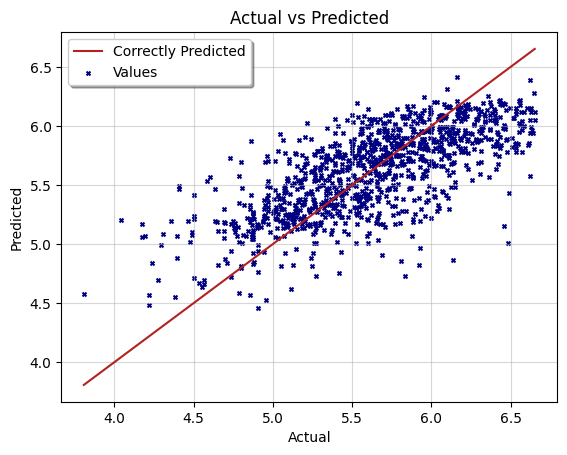

In [ ]:
## Add as many boxes as you like
plt.title('Actual vs Predicted')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='firebrick', label= 'Correctly Predicted')
plt.scatter(y_test, y_preds, marker= 'x', s=8, color = 'navy', label = 'Values')
plt.legend(shadow = True)
plt.plot()
plt.show()

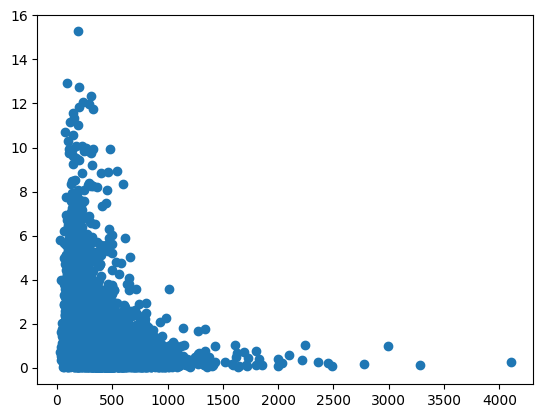

In [ ]:
plt.scatter(df1['price'], df1['reviews_per_month'])
plt.show()

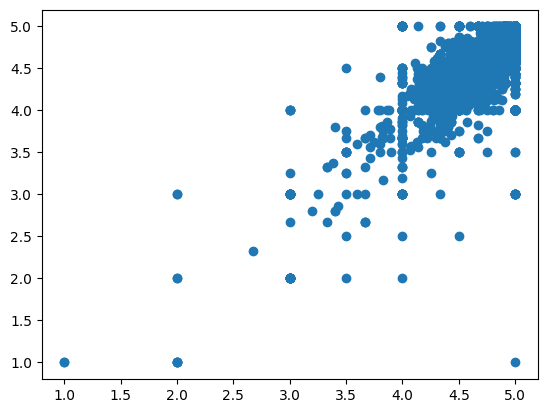

In [ ]:
plt.scatter(df['review_scores_rating'], df['review_scores_value'])
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_preds)
print(mse)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_preds)
print("R² Score:", r2)

oob_error = oob_error = 1 - rf_reg.oob_score_

print(oob_error)

list(zip(rf_reg.feature_names_in_, rf_reg.feature_importances_))

0.13179113369453707
R² Score: 0.5044632085063723
0.5134171762168251


[('reviews_per_month', np.float64(0.19919731274819155)),
 ('sentiments', np.float64(0.07619595485913759)),
 ('bathrooms', np.float64(0.34301119307540295)),
 ('review_scores_value', np.float64(0.07433723290147433)),
 ('review_scores_rating', np.float64(0.07148972072542054)),
 ('room_type', np.float64(0.14439642588950352)),
 ('amenities_count', np.float64(0.09137215980086955))]

In [ ]:
r2 = .49
n = len(y_test)
k = X.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
adj_r2

0.4866478873239436